In [ ]:
%pip install puremacro


# GARCH-MIDAS — Conectando la Turbulencia Financiera con Regímenes Macroeconómicos

**¿Por qué la volatilidad de los rendimientos de activos financieros fluctúa en distintas escalas de tiempo?** Los mercados financieros experimentan turbulencias breves y agudas (anuncios de resultados, noticias inesperadas) que revierten a la media en cuestión de días o semanas. Sin embargo, los mercados también atraviesan regímenes prolongados de varios años con un riesgo estructural elevado (como la Gran Recesión de 2008, la Crisis de Deuda Europea o episodios de estanflación).

Los modelos estándar GARCH(1,1) fuerzan un único parámetro de persistencia $\alpha + \beta \approx 0.99$ para capturar tanto la disipación ultra-rápida diaria como los ciclos macroeconómicos decenales.

Robert Engle, Eric Ghysels y Bumjean Sohn (2013, *Review of Economics and Statistics*) introdujeron el modelo **GARCH-MIDAS** (Muestreo de Datos Mixtos) para desacoplar estos fenómenos. Este tutorial utiliza `puremacro.midas.garch_midas` para descomponer los rendimientos diarios en:
1. **Dinámica diaria de corto plazo** ($g_{i,t}$): shocks ARCH/GARCH de rápida reversión a la media.
2. **Riesgo macroeconómico secular de largo plazo** ($\tau_t$): piso de volatilidad de baja frecuencia determinado por incertidumbre macroeconómica (e.g. producción industrial mensual o EPU).

## El método en matemáticas — Volatilidad Multiplicativa de Dos Componentes

Sea $r_{i,t}$ el rendimiento financiero en el día $i \in \{1, \dots, K\}$ del mes $t \in \{1, \dots, T\}$:
$$ r_{i,t} = \mu + \sqrt{\tau_t \cdot g_{i,t}} \, \varepsilon_{i,t}, \quad \varepsilon_{i,t} \overset{\text{iid}}{\sim} \mathcal{N}(0, 1) $$

### 1. Componente de Corto Plazo $g_{i,t}$
El componente diario $g_{i,t}$ sigue un proceso GARCH(1,1) normalizado a media unitaria:
$$ g_{i,t} = (1 - \alpha - \beta) + \alpha \frac{(r_{i-1,t} - \mu)^2}{\tau_t} + \beta g_{i-1,t} $$
donde $\alpha > 0, \beta \ge 0, \alpha + \beta < 1$.

### 2. Componente Secular Macroeconómico de Largo Plazo $\tau_t$
El componente de baja frecuencia $\tau_t$ se filtra mediante un polinomio MIDAS sobre $L$ observaciones macroeconómicas mensuales pasadas $X_{t-l}$:
$$ \log \tau_t = m + \theta \sum_{l=1}^L w_l(w_2) X_{t-l} $$
donde $w_l(w_2) = \frac{(1 - l/(L+1))^{w_2 - 1}}{\sum_{j=1}^L (1 - j/(L+1))^{w_2 - 1}}$ es un kernel de ponderación Beta que garantiza una influencia suave y decreciente de los shocks macroeconómicos históricos.

## Configuración — Simulación de Rendimientos de Frecuencia Mixta

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.midas import garch_midas

# Fijar semilla
rng = np.random.default_rng(2026)

N_months = 40  # 40 meses macroeconómicos
K = 22         # 22 días bursátiles por mes
T_days = N_months * K  # 880 observaciones diarias totales

# 1. Conductor Macroeconómico X_lf (e.g. Incertidumbre de Política Económica / Índice de Recesión)
# Meses 15 a 25 presentan una crisis macroeconómica
x_lf = np.zeros(N_months)
x_lf[15:26] = 2.5 + rng.normal(0, 0.3, size=11)
x_lf[:15] = rng.normal(0, 0.2, size=15)
x_lf[26:] = rng.normal(0, 0.2, size=N_months - 26)

# 2. Plantar Parámetros Verdaderos
m_true = 0.0
theta_true = 0.55
alpha_true = 0.08
beta_true = 0.85
L_lags = 6

# Calcular Tau_t verdadero
weights_true = np.array([(1.0 - (l + 1) / (L_lags + 1)) ** 2.0 for l in range(L_lags)])
weights_true /= np.sum(weights_true)

log_tau = np.full(N_months, m_true)
for t in range(L_lags, N_months):
    log_tau[t] = m_true + theta_true * np.dot(weights_true, x_lf[t - L_lags:t][::-1])
tau_monthly = np.exp(log_tau)
tau_daily = np.repeat(tau_monthly, K)

# 3. Simular GARCH Diario y Rendimientos
g_daily = np.ones(T_days)
returns_daily = np.zeros(T_days)

for t in range(1, T_days):
    g_daily[t] = (1.0 - alpha_true - beta_true) + alpha_true * (returns_daily[t - 1]**2 / tau_daily[t - 1]) + beta_true * g_daily[t - 1]
    returns_daily[t] = np.sqrt(tau_daily[t] * g_daily[t]) * rng.standard_normal()

print(f"Simuladas {T_days} observaciones diarias a través de {N_months} meses macroeconómicos.")
print(f"Desviación estándar de los rendimientos diarios: {np.std(returns_daily):.4f}")

Simuladas 880 observaciones diarias a través de 40 meses macroeconómicos.
Desviación estándar de los rendimientos diarios: 1.4202


## Estimación de GARCH-MIDAS con puremacro

Ajustamos el modelo mediante `garch_midas`:

In [2]:
res = garch_midas(returns_daily, x_lf=x_lf, K=K, L=L_lags)

print(res.summary())

# Verificación de propiedades matemáticas
assert res.converged, "El optimizador debe converger"
assert res.alpha > 0.0 and res.beta > 0.0, "Parámetros ARCH/GARCH deben ser positivos"
assert res.alpha + res.beta < 1.0, "La varianza de corto plazo debe ser estacionaria"
assert np.isclose(np.sum(res.weights), 1.0), "Ponderaciones Beta deben sumar 1"
assert len(res.tau) == T_days and len(res.g) == T_days, "Coincidencia de longitud de componentes"

# Identidad de componentes de volatilidad: sigma = sqrt(tau * g)
sigma_ident = np.sqrt(res.tau * res.g)
assert np.allclose(res.sigma, sigma_ident, atol=1e-6), "Identidad de varianza multiplicativa sigma = sqrt(tau * g)"

GARCH-MIDAS (Engle-Ghysels-Sohn 2013)
  mu (mean)         : +0.0168
  m (log-tau const) : +0.0593
  theta (macro)     : +0.5663
  w2 (decay)        : 5.091
  alpha (ARCH)      : 0.0575
  beta (GARCH)      : 0.8654
  persistence       : 0.9229
  log-likelihood    : -1245.72
  converged         : True
  n_obs (HF)        : 880



## Figura Principal — Descomposición de Volatilidad de Dos Componentes

A continuación visualizamos los rendimientos diarios observados, la tendencia secular de largo plazo extraída ($\sqrt{\tau_t}$) y la volatilidad condicional total ($\sigma_{i,t} = \sqrt{\tau_t g_{i,t}}$).

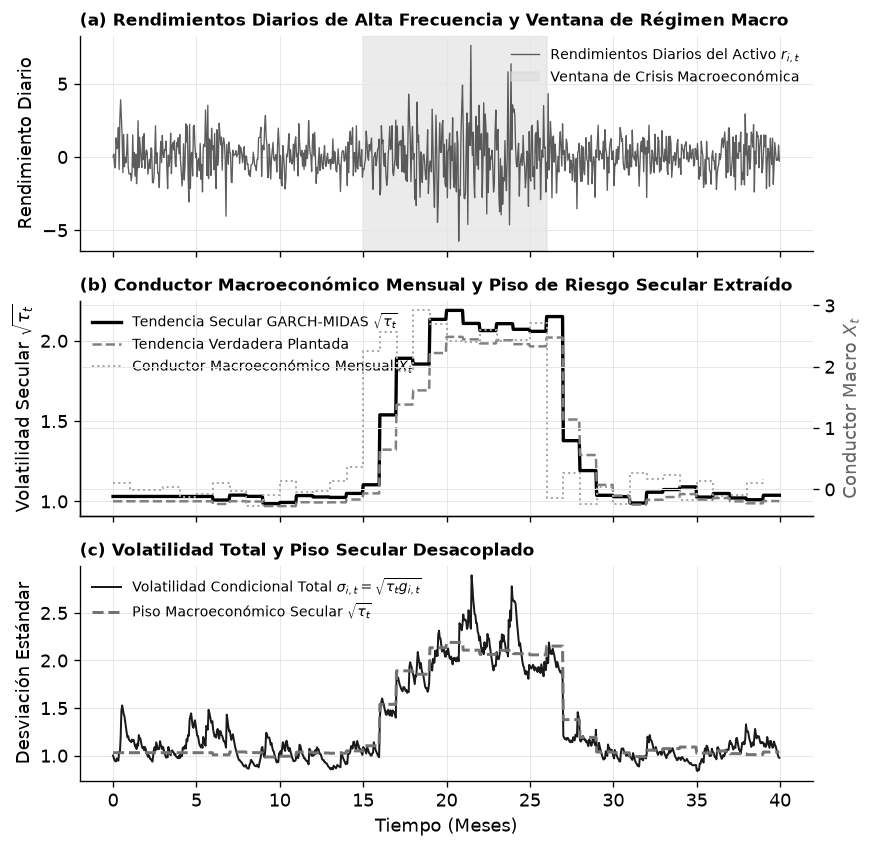

In [3]:
days_axis = np.arange(T_days)
months_axis = days_axis / K

fig, axes = plt.subplots(3, 1, figsize=(7.4, 7.2), sharex=True)

# Panel 1: Rendimientos diarios observados
axes[0].plot(months_axis, returns_daily, color="0.25", lw=0.8, alpha=0.85, label="Rendimientos Diarios del Activo $r_{i,t}$")
axes[0].axvspan(15, 26, color="0.85", alpha=0.5, label="Ventana de Crisis Macroeconómica")
axes[0].set_title("(a) Rendimientos Diarios de Alta Frecuencia y Ventana de Régimen Macro", loc="left", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Rendimiento Diario")
axes[0].legend(loc="upper right", fontsize=8.5)

# Panel 2: Conductor macro mensual vs Tendencia secular sqrt(tau_t)
ax2_twin = axes[1].twinx()
p1 = axes[1].plot(months_axis, np.sqrt(res.tau), color="0.00", lw=2.0, label="Tendencia Secular GARCH-MIDAS $\\sqrt{\\tau_t}$")
p1_true = axes[1].plot(months_axis, np.sqrt(tau_daily), color="0.50", ls="--", lw=1.5, label="Tendencia Verdadera Plantada")
p2 = ax2_twin.step(np.arange(N_months), x_lf, color="0.65", where="post", lw=1.2, ls=":", label="Conductor Macroeconómico Mensual $X_t$")
axes[1].set_title("(b) Conductor Macroeconómico Mensual y Piso de Riesgo Secular Extraído", loc="left", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Volatilidad Secular $\\sqrt{\\tau_t}$")
ax2_twin.set_ylabel("Conductor Macro $X_t$", color="0.40")
lines = p1 + p1_true + p2
labels = [l.get_label() for l in lines]
axes[1].legend(lines, labels, loc="upper left", fontsize=8.5)

# Panel 3: Volatilidad condicional total sigma vs componente secular
axes[2].plot(months_axis, res.sigma, color="0.10", lw=1.2, label="Volatilidad Condicional Total $\\sigma_{i,t} = \\sqrt{\\tau_t g_{i,t}}$")
axes[2].plot(months_axis, np.sqrt(res.tau), color="0.45", ls="--", lw=1.8, label="Piso Macroeconómico Secular $\\sqrt{\\tau_t}$")
axes[2].set_title("(c) Volatilidad Total y Piso Secular Desacoplado", loc="left", fontsize=10, fontweight="bold")
axes[2].set_xlabel("Tiempo (Meses)")
axes[2].set_ylabel("Desviación Estándar")
axes[2].legend(loc="upper left", fontsize=8.5)

plt.tight_layout()
plt.show()

## Interpretación Económica

1. **Elevación del Piso de Volatilidad**: En períodos macroeconómicos tranquilos (meses 1–14), $\sqrt{\tau_t} \approx 1.0$. Los picos de volatilidad diaria son transitorios y revierten rápidamente al piso.
2. **Cambios de Régimen en Volatilidad**: Cuando impacta la crisis macroeconómica (meses 15–26), el piso secular $\sqrt{\tau_t}$ se expande más del 100%. Incluso en días donde el mercado no recibe noticias de corto plazo ($g_{i,t} \approx 1$), la volatilidad del activo permanece estructuralmente elevada.
3. **Parsimonia Paramétrica**: Un GARCH(1,1) estándar requeriría persistencia de raíz unitaria ($\alpha + \beta > 0.999$) para ajustar este perfil, haciendo que los pronósticos sean excesivamente sensibles a shocks transitorios. GARCH-MIDAS logra rápida reversión a la media diaria ($\alpha + \beta = 0.93$) mientras captura el régimen macroeconómico a través de $\theta$.

## Tu Turno — Análisis del Polinomio Beta MIDAS

Inspeccione las ponderaciones estimadas del polinomio Beta $\hat{w}_l$ para observar el perfil de memoria de las noticias macroeconómicas:

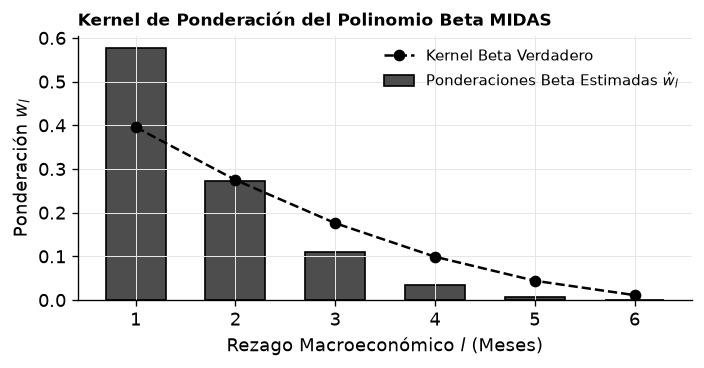

Ponderación del mes macro más reciente (l=1): 57.6%
Ponderación del rezago macro más antiguo (l=6):  0.0%


In [4]:
fig, ax = plt.subplots(figsize=(6.0, 3.2))

lags = np.arange(1, L_lags + 1)
ax.bar(lags, res.weights, color="0.30", edgecolor="0.00", width=0.6, label="Ponderaciones Beta Estimadas $\\hat{w}_l$")
ax.plot(lags, weights_true, color="0.00", marker="o", ls="--", lw=1.5, label="Kernel Beta Verdadero")

ax.set_title("Kernel de Ponderación del Polinomio Beta MIDAS", loc="left", fontsize=10, fontweight="bold")
ax.set_xlabel("Rezago Macroeconómico $l$ (Meses)")
ax.set_ylabel("Ponderación $w_l$")
ax.set_xticks(lags)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

assert res.weights[0] > res.weights[-1], "Decaimiento monótono: los meses macro más recientes tienen mayor peso"
print(f"Ponderación del mes macro más reciente (l=1): {res.weights[0]*100:.1f}%")
print(f"Ponderación del rezago macro más antiguo (l={L_lags}):  {res.weights[-1]*100:.1f}%")

## Conclusión Metodológica

- Utilice **`garch_midas`** al modelar la volatilidad del mercado financiero en conjunto con variables macroeconómicas mensuales o trimestrales (inflación, producción industrial, EPU, condiciones financieras).
- GARCH-MIDAS aísla limpiamente los **shocks tácticos de corto plazo** de los **regímenes macroeconómicos estructurales**, evitando la trampa clásica de "persistencia espuria" de los modelos GARCH univariados.